# Učitavanje podataka

U ovoj svesci učitavamo Flickr8k skup, analiziramo ga, delimo podatke na trening, validacioni i test skup i pripremamo slike i tekst za Mini-CLIP trening.

In [1]:
import os
import re
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from PIL import Image
import random
import torch

from torch.utils.data import Dataset, DataLoader

### Flickr8k dataset

Koristimo Flickr8k koji ima 8091 slika, i svaka slika ima po 5 opisa na engleskom jeziku, time imamo 40455 parova image-caption.

Izvor: [Kaggle Flickr8k](https://www.kaggle.com/datasets/adityajn105/flickr8k)

In [6]:
DATA_DIR = "../data"

IMAGES_DIR = os.path.join(
    DATA_DIR,
    "Images"
)

CAPTIONS_FILE = os.path.join(
    DATA_DIR,
    "captions.txt"
)

OUTPUT_DIR = os.path.join(
    DATA_DIR,
    "processed"
)

In [7]:
captions_df = pd.read_csv(CAPTIONS_FILE)

In [8]:
captions_df.shape

(40455, 2)

In [9]:
print("Number of caption pairs:", len(captions_df))
print("Number of images:", captions_df["image"].nunique())
captions_per_image = captions_df.groupby("image").size()

print(captions_per_image.value_counts())
captions_df.head(10)

Number of caption pairs: 40455
Number of images: 8091
5    8091
Name: count, dtype: int64


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
6,1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with...
7,1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots a...
8,1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each o...
9,1001773457_577c3a7d70.jpg,Two dogs on pavement moving toward each other .


Svih 8091 slika ima tačno 5 opisa.

Primer ispod prikazuje jednu sliku i jedan njoj pridruženi opis.

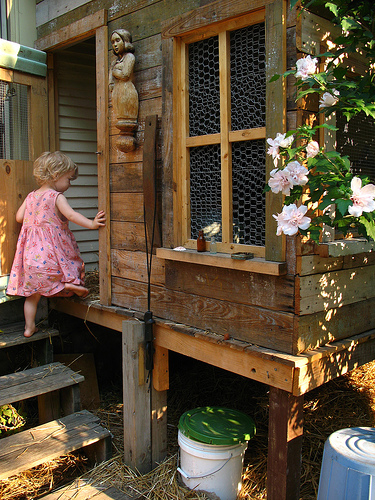

In [10]:
sample = captions_df.iloc[1]
image_path = os.path.join(IMAGES_DIR, sample["image"])
image = Image.open(image_path)
image

In [11]:
sample["caption"]

'A girl going into a wooden building .'

## Podela na trening, test i validacioni skup

In [12]:
unique_images = captions_df["image"].unique()

train_images, test_val_images = train_test_split(unique_images, test_size=0.2, random_state=42)
val_images, test_images = train_test_split(test_val_images, test_size=0.5, random_state=42)

train_df = captions_df[captions_df["image"].isin(train_images)].reset_index(drop=True)
val_df = captions_df[captions_df["image"].isin(val_images)].reset_index(drop=True)
test_df = captions_df[captions_df["image"].isin(test_images)].reset_index(drop=True)


In [13]:
train_df.shape

(32360, 2)

In [14]:
val_df.shape

(4045, 2)

In [15]:
test_df.shape

(4050, 2)

Kako svaka slika ima po 5 opisa, moramo voditi računa da jedna slika ne završi i u trening i u test skupu. Ako bi završila, imali bismo curenje podataka.

## Priprema slika za image encoder

In [16]:
import torchvision.transforms as transforms

In [17]:
sizes = []
for filename in train_images:
    path = os.path.join(IMAGES_DIR, filename)
    with Image.open(path) as img:
        sizes.append(img.size)

size_counts = Counter(sizes)

print(f"Number of unique image dimensions: {len(size_counts)}")

Number of unique image dimensions: 552


Nisu sve slike istih dimenzija, vidimo da imamo čak 552 različite dimenzije na skupu od 8091 slika.
Potrebno je da ih pre obrade dovedemo na istu rezoluciju.

1. **Resize((224,224))** - standardna veličina za ResNet18
2. **ToTensor()** - transformiše PIL u tensor
3. **Normalize(IMAGENET_MEAN, IMAGENET_STD)** - za svaki RGB kanal oduzimamo prosečnu vrednost i delimo standardnom devijacijom. U IMAGENET_MEAN i IMAGENET_STD su fiksne ImageNet statistike (ne računamo iz na Flickr8k), a pretrained ResNet18 je učen upravo na ovako pripremljenim slikama, zato moramo primeniti isti korak i na našim slikama.

U ContrastiveFlickrDataset-u svaka slika se učitava sa `.convert("RGB")` (grayscale/RGBA -> RGB).

NAPOMENA: `Resize((224,224))` ne čuva odnos širine i visine - slika se rasteže.

In [18]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

## Priprema opisa za text encoder

In [19]:
def normalize_text(text):
    text = text.lower().strip()
    return text

In [20]:
train_df["caption"] = train_df["caption"].apply(normalize_text)
val_df["caption"] = val_df["caption"].apply(normalize_text)
test_df["caption"] = test_df["caption"].apply(normalize_text)

In [21]:
train_df.head()

,image,caption
0,1000268201_693b08cb0e.jpg,a child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,a girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,a little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,a little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,a little girl in a pink dress going into a woo...


#### Tokenizacija teksta

In [22]:
def tokenize(text):
    return re.findall(r"\w+|[^\w\s]", text)

In [23]:
for caption in train_df["caption"].head(5):
    print(caption)
    print(tokenize(caption))
    print()

a child in a pink dress is climbing up a set of stairs in an entry way .
['a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', 'entry', 'way', '.']

a girl going into a wooden building .
['a', 'girl', 'going', 'into', 'a', 'wooden', 'building', '.']

a little girl climbing into a wooden playhouse .
['a', 'little', 'girl', 'climbing', 'into', 'a', 'wooden', 'playhouse', '.']

a little girl climbing the stairs to her playhouse .
['a', 'little', 'girl', 'climbing', 'the', 'stairs', 'to', 'her', 'playhouse', '.']

a little girl in a pink dress going into a wooden cabin .
['a', 'little', 'girl', 'in', 'a', 'pink', 'dress', 'going', 'into', 'a', 'wooden', 'cabin', '.']



Specijalni tokeni:

"\<PAD>" → padding

"\<UNK>" → unknown token

"\<SOS>" → start of sequence

"\<EOS>" → end of sequence

In [24]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"

#### Pravljenje vokabulara

In [25]:
class Vocabulary:
    def __init__(self, min_freq=1):
        self.min_freq = min_freq

        self.token_to_id = {
            PAD_TOKEN: 0,
            UNK_TOKEN: 1,
            SOS_TOKEN: 2,
            EOS_TOKEN: 3,
        }

        self.id_to_token = {
            0: PAD_TOKEN,
            1: UNK_TOKEN,
            2: SOS_TOKEN,
            3: EOS_TOKEN,
        }

    def build(self, captions):
        counter = Counter()

        for caption in captions:
            tokens = tokenize(caption)
            counter.update(tokens)

        for token, frequency in sorted(counter.items()):
            if frequency >= self.min_freq:
                if token not in self.token_to_id:
                    idx = len(self.token_to_id)

                    self.token_to_id[token] = idx
                    self.id_to_token[idx] = token

    def __len__(self):
        return len(self.token_to_id)

In [26]:
vocab = Vocabulary(min_freq=1)

vocab.build(train_df["caption"])

print("Vocabulary size:", len(vocab))

Vocabulary size: 7747


In [27]:
for token, idx in list(vocab.token_to_id.items())[::200]:
    print(f"{idx:4d} -> {token}")

   0 -> <PAD>
 200 -> amazing
 400 -> avoid
 600 -> beckons
 800 -> booklets
1000 -> business
1200 -> ceramic
1400 -> cluster
1600 -> costumes
1800 -> dangles
2000 -> dolls
2200 -> elephants
2400 -> falls
2600 -> floaters
2800 -> gate
3000 -> grips
3200 -> helplessly
3400 -> inch
3600 -> keeping
3800 -> library
4000 -> marked
4200 -> moter
4400 -> notices
4600 -> packer
4800 -> perched
5000 -> pokemon
5200 -> proximity
5400 -> redish
5600 -> rough
5800 -> seeds
6000 -> silky
6200 -> snowed
6400 -> squating
6600 -> struggles
6800 -> tambourines
7000 -> toll
7200 -> twenty
7400 -> wagging
7600 -> windsurfing


In [28]:
def encode_text(text, vocab):
    tokens = tokenize(text)

    tokens = [
        SOS_TOKEN,
        *tokens,
        EOS_TOKEN
    ]

    return [
        vocab.token_to_id.get(token, vocab.token_to_id[UNK_TOKEN])
        for token in tokens
    ]


example = "a little girl is running"

encoded = encode_text(example, vocab)

print("Text:")
print(example)

print("\nToken IDs:")
print(encoded)

Text:
a little girl is running

Token IDs:
[2, 60, 3859, 2849, 3480, 5638, 3]


In [29]:
def decode_ids(ids, vocab):
    return [
        vocab.id_to_token[int(idx)]
        for idx in ids
    ]

tokens = decode_ids(encoded, vocab)

print(tokens)

['<SOS>', 'a', 'little', 'girl', 'is', 'running', '<EOS>']


#### Padding

In [30]:
MAX_LENGTH = 32
def pad_or_truncate(ids, max_length, pad_id):
    if len(ids) > max_length:
        ids = ids[:max_length]
        ids[-1] = vocab.token_to_id[EOS_TOKEN]

    else:
        ids = ids + [pad_id] * (max_length - len(ids))

    return ids

In [31]:
def preprocess_text(text, vocab, max_length):
    text = normalize_text(text)

    ids = encode_text(text, vocab)

    ids = pad_or_truncate(
        ids,
        max_length,
        vocab.token_to_id[PAD_TOKEN]
    )

    return ids

In [32]:
train_df["input_ids"] = train_df["caption"].apply(
    lambda x: preprocess_text(x, vocab, MAX_LENGTH)
)

val_df["input_ids"] = val_df["caption"].apply(
    lambda x: preprocess_text(x, vocab, MAX_LENGTH)
)

test_df["input_ids"] = test_df["caption"].apply(
    lambda x: preprocess_text(x, vocab, MAX_LENGTH)
)

In [33]:
print(train_df[["caption", "input_ids"]].head())

                                             caption  \
0  a child in a pink dress is climbing up a set o...   
1              a girl going into a wooden building .   
2   a little girl climbing into a wooden playhouse .   
3  a little girl climbing the stairs to her playh...   
4  a little girl in a pink dress going into a woo...   

                                           input_ids  
0  [2, 60, 1275, 3398, 60, 4905, 2068, 3480, 1367...  
1  [2, 60, 2849, 2897, 3464, 60, 7642, 953, 13, 3...  
2  [2, 60, 3859, 2849, 1367, 3464, 60, 7642, 4965...  
3  [2, 60, 3859, 2849, 1367, 6895, 6430, 6987, 32...  
4  [2, 60, 3859, 2849, 3398, 60, 4905, 2068, 2897...  


In [34]:
row = train_df.iloc[0]

print("Caption:")
print(row["caption"])

print("\nIDs:")
print(row["input_ids"])

print("\nDecoded:")
print(decode_ids(row["input_ids"], vocab))

Caption:
a child in a pink dress is climbing up a set of stairs in an entry way .

IDs:
[2, 60, 1275, 3398, 60, 4905, 2068, 3480, 1367, 7275, 60, 5833, 4454, 6430, 3398, 216, 2273, 7487, 13, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Decoded:
['<SOS>', 'a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', 'entry', 'way', '.', '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']


In [35]:
def create_attention_mask(ids, pad_id):
    return [
        0 if token_id == pad_id else 1
        for token_id in ids
    ]

In [36]:
PAD_ID = vocab.token_to_id[PAD_TOKEN]

train_df["attention_mask"] = train_df["input_ids"].apply(
    lambda ids: create_attention_mask(ids, PAD_ID)
)

val_df["attention_mask"] = val_df["input_ids"].apply(
    lambda ids: create_attention_mask(ids, PAD_ID)
)

test_df["attention_mask"] = test_df["input_ids"].apply(
    lambda ids: create_attention_mask(ids, PAD_ID)
)

In [37]:
row = train_df.iloc[0]

print("Input IDs:")
print(row["input_ids"])

print("\nAttention mask:")
print(row["attention_mask"])

Input IDs:
[2, 60, 1275, 3398, 60, 4905, 2068, 3480, 1367, 7275, 60, 5833, 4454, 6430, 3398, 216, 2273, 7487, 13, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Attention mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


#### Statistike duzine opisa

In [38]:
token_lengths = train_df["caption"].apply(
    lambda x: len(tokenize(x)) + 2  # + SOS + EOS
)

print(token_lengths.describe())

num_truncated = (token_lengths > MAX_LENGTH).sum()

print("Captions:", len(token_lengths))
print("Truncated:", num_truncated)
print(
    "Percentage:",
    100 * num_truncated / len(token_lengths)
)

count    32360.000000
mean        13.856211
std          3.949807
min          3.000000
25%         11.000000
50%         13.000000
75%         16.000000
max         42.000000
Name: caption, dtype: float64
Captions: 32360
Truncated: 24
Percentage: 0.07416563658838071


#### Čuvanje vokabulara i podataka

In [39]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

vocab_path = os.path.join(
    OUTPUT_DIR,
    "vocab.json"
)

with open(vocab_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "token_to_id": vocab.token_to_id,
            "id_to_token": {
                str(k): v
                for k, v in vocab.id_to_token.items()
            },
            "max_length": MAX_LENGTH
        },
        f,
        indent=2,
        ensure_ascii=False
    )

In [40]:
train_df.to_csv(
    os.path.join(OUTPUT_DIR, "train.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(OUTPUT_DIR, "val.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(OUTPUT_DIR, "test.csv"),
    index=False
)

In [41]:
train_df.head()

,image,caption,input_ids,attention_mask
0,1000268201_693b08cb0e.jpg,a child in a pink dress is climbing up a set o...,"[2, 60, 1275, 3398, 60, 4905, 2068, 3480, 1367...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,1000268201_693b08cb0e.jpg,a girl going into a wooden building .,"[2, 60, 2849, 2897, 3464, 60, 7642, 953, 13, 3...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ..."
2,1000268201_693b08cb0e.jpg,a little girl climbing into a wooden playhouse .,"[2, 60, 3859, 2849, 1367, 3464, 60, 7642, 4965...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, ..."
3,1000268201_693b08cb0e.jpg,a little girl climbing the stairs to her playh...,"[2, 60, 3859, 2849, 1367, 6895, 6430, 6987, 32...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ..."
4,1000268201_693b08cb0e.jpg,a little girl in a pink dress going into a woo...,"[2, 60, 3859, 2849, 3398, 60, 4905, 2068, 2897...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


## Pravljenje Dataset-a i DataLoader-a

### Dataset za contrastive training

Za contrastive training jedan uzorak predstavlja jednu jedinstvenu sliku i
jedan njen odgovarajući caption.

Pošto Flickr8k sadrži pet caption-a za svaku sliku, dataset je organizovan
tako da se svaka slika pojavljuje samo jednom. Tokom treninga se za svaku
sliku nasumično bira jedan od njenih pet caption-a.

Na ovaj način se u istom batch-u ne pojavljuje ista slika više puta sa
različitim ispravnim caption-ima. Time se izbegava da jedan validan caption
iste slike bude pogrešno tretiran kao negativan primer u contrastive loss-u.

Za validation skup koristi se fiksni caption za svaku sliku kako bi rezultati
evaluacije bili konzistentni između epoha.

In [42]:
class ContrastiveFlickrDataset(Dataset):
    def __init__(self, df, images_dir, transform=None, random_caption=True):
        self.df = df
        self.images_dir = images_dir
        self.transform = transform
        self.random_caption = random_caption

        self.image_names = self.df["image"].unique()

        self.captions_by_image = {
            image_name: group.reset_index(drop=True)
            for image_name, group in self.df.groupby("image")
        }

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]

        captions = self.captions_by_image[image_name]

        if self.random_caption:
            row_index = random.randrange(len(captions))
        else:
            row_index = 0

        row = captions.iloc[row_index]

        image_path = os.path.join(self.images_dir, image_name)
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        input_ids = torch.tensor(
            row["input_ids"],
            dtype=torch.long
        )

        attention_mask = torch.tensor(
            row["attention_mask"],
            dtype=torch.long
        )

        return {
            "image": image,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "caption": row["caption"],
            "image_name": image_name
        }

In [43]:
CONTRASTIVE_BATCH_SIZE = 32

contrastive_train_dataset = ContrastiveFlickrDataset(
    train_df,
    IMAGES_DIR,
    transform=image_transform,
    random_caption=True
)

contrastive_val_dataset = ContrastiveFlickrDataset(
    val_df,
    IMAGES_DIR,
    transform=image_transform,
    random_caption=False
)

contrastive_train_loader = DataLoader(
    contrastive_train_dataset,
    batch_size=CONTRASTIVE_BATCH_SIZE,
    shuffle=True
)

contrastive_val_loader = DataLoader(
    contrastive_val_dataset,
    batch_size=CONTRASTIVE_BATCH_SIZE,
    shuffle=False
)